# nb04_v10_benchmark (headline cross-pipeline comparison)

Consolidates Phase C/D/E results into a unified view. Loads per-cell and ensemble CSVs from `results/` for three pipelines (opx, cpx, twopx) and produces:

1. Unified best-RMSE table
2. Cross-pipeline heatmap (headline figure)
3. Winning-base histogram (which family wins most often?)
4. Ensemble-vs-best-base delta per pipeline

**Scope:** internal ML comparison only. External models (Agreda, Jorgenson, Petrelli, Wang, Putirka) are integrated in the follow-up benchmark (Phase G.1b). The universal model is excluded from this notebook as of 2026-04-18 (later-project scope).

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 50)


## Load per-pipeline results

Per-cell CSVs carry one row per (model, target, track, feature_set). Ensemble CSVs carry one row per (method, target, track, feature_set).


In [2]:
pipelines = {
    'opx':       RESULTS / 'v10_opx_per_cell_results.csv',
    'cpx':       RESULTS / 'v10_cpx_per_cell_results.csv',
    'twopx':     RESULTS / 'v10_twopx_per_cell_results.csv',
    # 'universal' excluded 2026-04-18: scope limited to cpx/opx/twopx for the
    # current paper; universal is a later project.
}
ens_paths = {
    'opx':       RESULTS / 'v10_opx_ensemble_results.csv',
    'cpx':       RESULTS / 'v10_cpx_ensemble_results.csv',
    'twopx':     RESULTS / 'v10_twopx_ensemble_results.csv',
}

frames_base, frames_ens = [], []
for p, path in pipelines.items():
    df = pd.read_csv(path)
    df['pipeline'] = p
    frames_base.append(df)
for p, path in ens_paths.items():
    df = pd.read_csv(path)
    df['pipeline'] = p
    frames_ens.append(df)

all_bases = pd.concat(frames_base, ignore_index=True)
all_ens   = pd.concat(frames_ens, ignore_index=True)
print(f'base rows: {len(all_bases)}  ensemble rows: {len(all_ens)}')

base rows: 256  ensemble rows: 96


## Unified best-RMSE table
Per (pipeline, target, track): winning base model + winning ensemble method.


In [3]:
idx_b = all_bases.groupby(['pipeline','target','track'])['test_rmse'].idxmin()
best_b = all_bases.loc[idx_b, ['pipeline','target','track','model','feature_set','test_rmse']]
best_b = best_b.rename(columns={'model':'best_base','test_rmse':'base_rmse','feature_set':'base_fs'})

idx_e = all_ens.groupby(['pipeline','target','track'])['test_rmse'].idxmin()
best_e = all_ens.loc[idx_e, ['pipeline','target','track','method','feature_set','test_rmse']]
best_e = best_e.rename(columns={'method':'best_ens','test_rmse':'ens_rmse','feature_set':'ens_fs'})

unified = best_b.merge(best_e, on=['pipeline','target','track'], how='outer')
unified['ensemble_gain'] = unified['base_rmse'] - unified['ens_rmse']
unified = unified.sort_values(['target', 'pipeline', 'track']).reset_index(drop=True)
unified.round(3)


,pipeline,target,track,best_base,base_fs,base_rmse,best_ens,ens_fs,ens_rmse,ensemble_gain
0,cpx,P_kbar,cpx_liq,LightGBM,pwlr,6.537,ridge,pwlr,6.522,0.015
1,cpx,P_kbar,cpx_only,MLP,alr,13.466,two_level,raw,14.285,-0.819
2,opx,P_kbar,opx_liq,MLP,raw,3.816,greedy,raw,3.825,-0.010
3,opx,P_kbar,opx_only,XGB,pwlr,10.202,ridge,pwlr,10.178,0.023
4,twopx,P_kbar,twopx,XGB,alr,4.263,greedy,pwlr,4.514,-0.251
5,cpx,T_C,cpx_liq,CatBoost,pwlr,71.571,ridge,pwlr,68.360,3.210
6,cpx,T_C,cpx_only,ERT,pwlr,127.350,two_level,pwlr,128.882,-1.532
7,opx,T_C,opx_liq,ElasticNet,raw,77.062,greedy,raw,78.025,-0.963
8,opx,T_C,opx_only,LightGBM,alr,147.982,ridge,alr,149.577,-1.595
9,twopx,T_C,twopx,ElasticNet,raw,79.536,greedy,pwlr,81.040,-1.505


## Figure 1: cross-pipeline headline heatmap

Rows = (pipeline, track), columns = target. Color = best base RMSE. Lower (darker) is better.


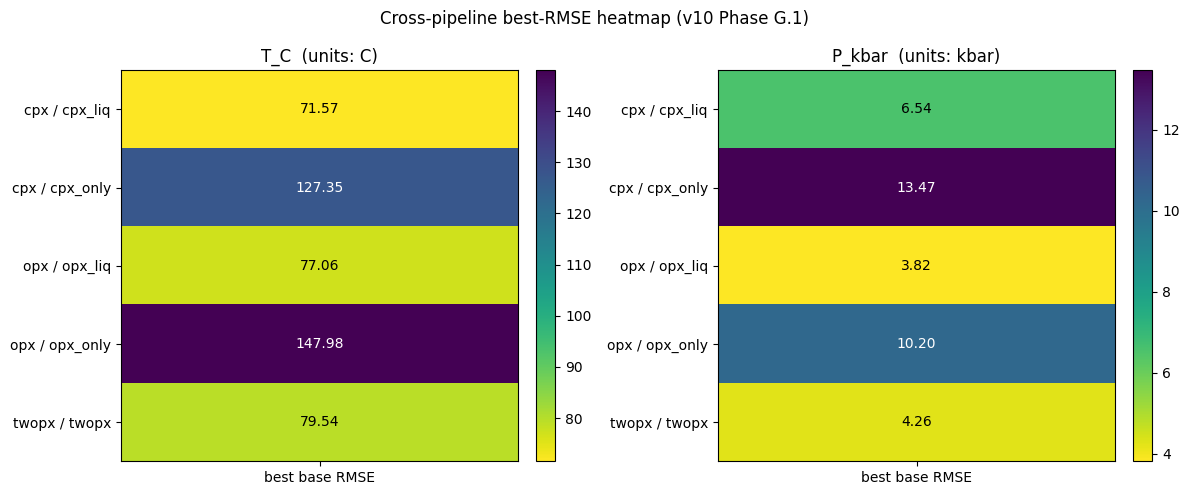

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_cross_pipeline_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = unified[unified['target']==tgt].copy()
    sub['row'] = sub['pipeline'] + ' / ' + sub['track']
    rows = sub['row'].tolist()
    vals = sub['base_rmse'].values.reshape(-1, 1)
    im = ax.imshow(vals, cmap='viridis_r', aspect='auto')
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xticks([0])
    ax.set_xticklabels([f'best base RMSE'])
    for i, v in enumerate(sub['base_rmse'].values):
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > sub['base_rmse'].median() else 'black',
                fontsize=10)
    ax.set_title(f'{tgt}  (units: {"C" if tgt=="T_C" else "kbar"})')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Cross-pipeline best-RMSE heatmap (v10 Phase G.1)', fontsize=12)
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_cross_pipeline_heatmap.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Figure 2: winning base family across all 10 cells

Counts, across the 10 (pipeline, target, track) cells, how many times each base-model family wins. Signals which family to treat as the primary recommendation.


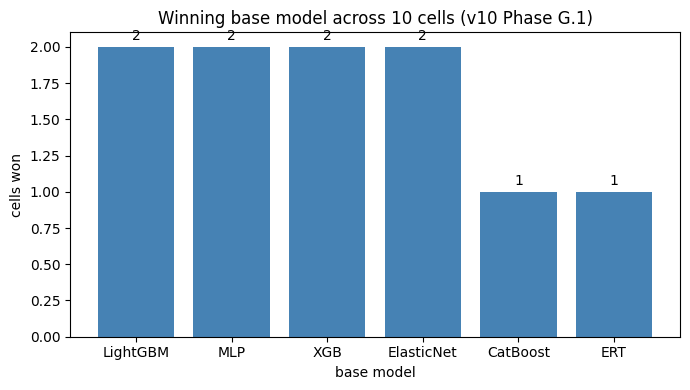

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_winning_base_histogram.png


In [5]:
win_counts = unified['best_base'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(win_counts.index, win_counts.values, color='steelblue')
ax.set_ylabel('cells won'); ax.set_xlabel('base model')
ax.set_title('Winning base model across 10 cells (v10 Phase G.1)')
for i, v in enumerate(win_counts.values):
    ax.text(i, v + 0.05, str(v), ha='center', fontsize=10)
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_winning_base_histogram.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Figure 3: ensemble-vs-base delta per cell

Positive `ensemble_gain` means the ensemble beat the best single base. Near-zero or negative means the best single base was already hard to beat. Bars colored by target.


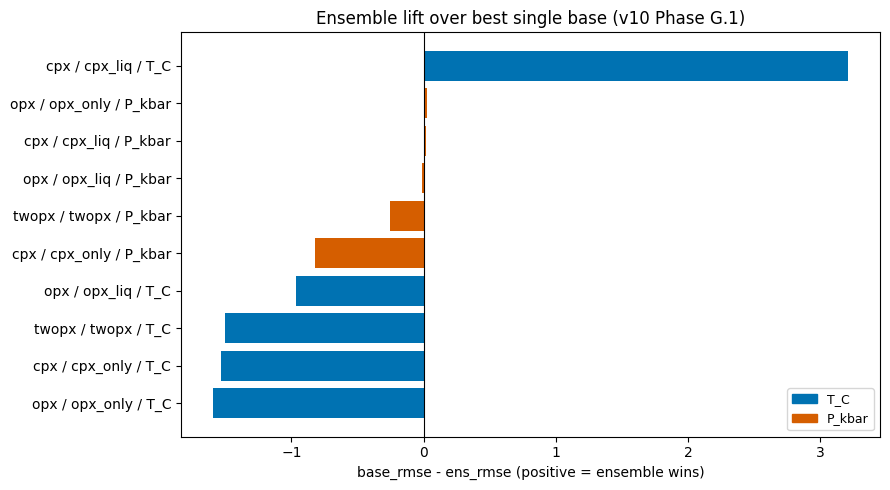

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_ensemble_lift.png


In [6]:
tmp = unified.copy()
tmp['cell'] = tmp['pipeline'] + ' / ' + tmp['track'] + ' / ' + tmp['target']
tmp = tmp.sort_values('ensemble_gain')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#0072B2' if t == 'T_C' else '#D55E00' for t in tmp['target']]
ax.barh(tmp['cell'], tmp['ensemble_gain'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('base_rmse - ens_rmse (positive = ensemble wins)')
ax.set_title('Ensemble lift over best single base (v10 Phase G.1)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#0072B2', label='T_C'),
                   Patch(color='#D55E00', label='P_kbar')],
          fontsize=9, loc='lower right')
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_ensemble_lift.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Summary table: written to disk

Saves the unified best-RMSE table to `results/v10_phase_g1_unified_best.csv` for downstream use by manuscript + other notebooks.


In [7]:
out_csv = RESULTS / 'v10_phase_g1_unified_best.csv'
unified.to_csv(out_csv, index=False)
print(f'saved {out_csv}')
print(f'\nShape: {unified.shape}')


saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_phase_g1_unified_best.csv

Shape: (10, 10)


# Per-regime calibration-domain characterization (pre-registered 2026-04-17)

Pre-registration: `docs/v10_p_regime_preregistration.md`. Bin edges locked at `[0, 5, 15, 30, 100]` kbar with labels `shallow_crustal`, `deep_crustal_MASH`, `lithospheric_mantle`, `deeper_mantle`. Registration timestamp precedes every per-regime result file in the git log.

**Framing:** this section is *calibration-domain characterization*, not a performance ranking. Claims of the form "method A beats method B in regime X" require BOTH (i) non-overlapping bootstrap 95% CIs and (ii) n >= 20 in the regime. Otherwise the bins are reported with their CIs and labelled "competitive with" or "indistinguishable from."

**Scope of this notebook section:** opx_liq is the opx paper's flagship track. Per-regime results for cpx and twopx live in the same source CSV but are reserved for the cpx paper; they are summarized here only in the headline table.

### Load the all-models regime benchmark CSV

**Input:** `results/v10_regime_allmodels.csv` (produced by `scripts/v10_phase_g_regime_allmodels.py`). One row per (pipeline, track, target, method_family, method, regime_type, regime).

**Output:** two DataFrames in memory — `df_reg` (full long-format table) and `df_opx` (filtered to opx_liq + the four pre-registered bins).

**Method:** read the CSV, restrict to the pre-registered P-regime labels `shallow_crustal`, `deep_crustal_MASH`, `lithospheric_mantle`, `deeper_mantle` (ignore the exploratory finer bins here). Cite `config.P_REGIME_LABELS` as the authority.

**Connection:** every downstream cell in this section consumes `df_opx`. Upstream: `scripts/v10_phase_g_regime_allmodels.py`.

**Why:** we keep the pre-registered four-bin partition as the headline; the exploratory bins remain in the CSV for secondary inspection but are not plotted in the opx paper per the pre-registration doc.

In [8]:
from config import (
    P_REGIME_LABELS, P_REGIME_BIN_EDGES_KBAR,
    P_REGIME_REGISTERED_DATE, P_REGIME_MIN_N_FOR_CLAIMS,
)
print(f'Pre-registered: {P_REGIME_REGISTERED_DATE}')
print(f'Bin edges (kbar): {P_REGIME_BIN_EDGES_KBAR}')
print(f'Labels: {P_REGIME_LABELS}')
print(f'Sample-size floor for claims: n >= {P_REGIME_MIN_N_FOR_CLAIMS}')

reg_csv = RESULTS / 'v10_regime_allmodels.csv'
df_reg = pd.read_csv(reg_csv)
print(f'\n{reg_csv.name}: {df_reg.shape[0]} rows, {df_reg.shape[1]} cols')
print(f'tracks present: {sorted(df_reg.track.unique())}')
print(f'regime labels present: {sorted(df_reg.regime.unique())}')

# Pre-registered opx subset for downstream cells.
df_opx = df_reg[(df_reg.track == 'opx_liq')
                & (df_reg.regime_type == 'P')
                & (df_reg.regime.isin(P_REGIME_LABELS))].copy()
print(f'\nopx_liq pre-registered rows: {len(df_opx)}')
df_opx.head(8)

Pre-registered: 2026-04-17
Bin edges (kbar): [0.0, 5.0, 15.0, 30.0, 100.0]
Labels: ['shallow_crustal', 'deep_crustal_MASH', 'lithospheric_mantle', 'deeper_mantle']
Sample-size floor for claims: n >= 20

v10_regime_allmodels.csv: 4667 rows, 18 cols
tracks present: ['cpx_liq', 'cpx_only', 'opx_liq', 'opx_only', 'twopx', 'universal']
regime labels present: ['1000<=T<1200', '10<=P<20', '1200<=T<1400', '20<=P<40', '5<=P<10', '800<=T<1000', 'ALL', 'P<20 (Agreda range)', 'P<5', 'P>=40', 'T<800', 'T>=1400', 'deep_crustal_MASH', 'deeper_mantle', 'lithospheric_mantle', 'shallow_crustal']

opx_liq pre-registered rows: 208


,pipeline,track,target,regime_type,regime,regime_lo,regime_hi,n,method_family,method,method_label,rmse,rmse_lo,rmse_hi,mae,mae_lo,mae_hi,n_used
0,opx,opx_liq,T_C,P,shallow_crustal,0.0,5.0,47,v10,RF/raw,v10 RF raw,30.139433,22.435093,38.667086,22.703909,17.890308,29.135229,47
1,opx,opx_liq,T_C,P,shallow_crustal,0.0,5.0,47,v10,RF/alr,v10 RF alr,36.879760,28.121029,44.681237,28.160487,21.829609,35.031351,47
2,opx,opx_liq,T_C,P,shallow_crustal,0.0,5.0,47,v10,RF/pwlr,v10 RF pwlr,30.512201,21.644210,39.930351,23.131862,17.907040,29.272346,47
3,opx,opx_liq,P_kbar,P,shallow_crustal,0.0,5.0,47,v10,RF/raw,v10 RF raw,6.539513,5.399348,7.683741,5.430726,4.388171,6.551705,47
4,opx,opx_liq,P_kbar,P,shallow_crustal,0.0,5.0,47,v10,RF/alr,v10 RF alr,5.659581,4.671516,6.583746,4.740618,3.838669,5.665985,47
5,opx,opx_liq,P_kbar,P,shallow_crustal,0.0,5.0,47,v10,RF/pwlr,v10 RF pwlr,6.567141,5.835551,7.200218,5.972728,5.160389,6.686354,47
6,opx,opx_liq,T_C,P,shallow_crustal,0.0,5.0,47,v10,ERT/raw,v10 ERT raw,29.530168,21.729987,36.987093,22.843024,17.749614,28.585237,47
7,opx,opx_liq,T_C,P,shallow_crustal,0.0,5.0,47,v10,ERT/alr,v10 ERT alr,34.055704,25.784930,42.043854,25.801988,19.727475,32.379935,47


### Build the per-regime headline summary (opx_liq, T and P)

**Input:** `df_opx` from the previous cell.

**Output:** `opx_per_regime` — headline DataFrame with one row per (regime, target), columns `v10_best_{method, rmse, rmse_lo, rmse_hi}`, `putirka_{method, rmse, rmse_lo, rmse_hi}`, `n`, `ci_overlap`, `sample_size_limited`. Saved to `results/v10_opx_per_regime_benchmark.csv`.

**Method:** for each (regime, target) group, pick the v10 row with minimum RMSE (v10 "best cell") and the Putirka row with minimum RMSE (Putirka "best equation"). Compute `ci_overlap` as True if the two bootstrap 95% CIs overlap, False otherwise. Flag `sample_size_limited = n < P_REGIME_MIN_N_FOR_CLAIMS`.

**Connection:** consumed by the plotting cell below and by `nbF_figures.ipynb` Figure 24. The CSV is also the source of manuscript Table X and SI Table S8.5.2.

**Why:** the headline claim per regime is "v10 vs Putirka best" at this honesty bar (CI non-overlap AND n >= 20). Agreda 2024 does not have an opx-liq model, so this cell holds the opx paper's primary external comparison.

In [9]:
def _ci_overlap(lo1, hi1, lo2, hi2):
    """Two intervals [lo1, hi1] and [lo2, hi2] overlap iff max(lo) <= min(hi)."""
    if not all(np.isfinite(x) for x in (lo1, hi1, lo2, hi2)):
        return np.nan
    return bool(max(lo1, lo2) <= min(hi1, hi2))


rows = []
for regime in P_REGIME_LABELS:
    for target in ('T_C', 'P_kbar'):
        sub = df_opx[(df_opx.regime == regime) & (df_opx.target == target)]
        if sub.empty:
            continue
        n = int(sub.n.iloc[0])
        # v10 best cell (lowest RMSE among v10 family).
        v10 = sub[sub.method_family == 'v10']
        v10 = v10.loc[v10.rmse.idxmin()] if not v10.empty else None
        # Putirka best equation (lowest RMSE among Putirka equations).
        put = sub[sub.method_family == 'Putirka']
        put = put.loc[put.rmse.idxmin()] if not put.empty else None

        row = {
            'regime': regime, 'target': target, 'n': n,
            'sample_size_limited': n < P_REGIME_MIN_N_FOR_CLAIMS,
        }
        if v10 is not None:
            row.update({
                'v10_method':  v10['method'],
                'v10_rmse':    float(v10['rmse']),
                'v10_rmse_lo': float(v10['rmse_lo']),
                'v10_rmse_hi': float(v10['rmse_hi']),
            })
        if put is not None:
            row.update({
                'putirka_method':  put['method'],
                'putirka_rmse':    float(put['rmse']),
                'putirka_rmse_lo': float(put['rmse_lo']),
                'putirka_rmse_hi': float(put['rmse_hi']),
            })
        if v10 is not None and put is not None:
            row['ci_overlap'] = _ci_overlap(
                row['v10_rmse_lo'], row['v10_rmse_hi'],
                row['putirka_rmse_lo'], row['putirka_rmse_hi'],
            )
            row['v10_beats_putirka'] = (
                (row['v10_rmse'] < row['putirka_rmse'])
                and (row['ci_overlap'] is False)
                and (not row['sample_size_limited'])
            )
        rows.append(row)

opx_per_regime = pd.DataFrame(rows)
out_csv = RESULTS / 'v10_opx_per_regime_benchmark.csv'
opx_per_regime.to_csv(out_csv, index=False)
print(f'saved {out_csv}  shape={opx_per_regime.shape}')
opx_per_regime.round(3)

saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_opx_per_regime_benchmark.csv  shape=(8, 14)


,regime,target,n,sample_size_limited,v10_method,v10_rmse,v10_rmse_lo,v10_rmse_hi,putirka_method,putirka_rmse,putirka_rmse_lo,putirka_rmse_hi,ci_overlap,v10_beats_putirka
0,shallow_crustal,T_C,47,False,ERT/pwlr,23.470,15.891,30.399,Putirka 28a,25.524,16.322,33.871,True,False
1,shallow_crustal,P_kbar,47,False,ElasticNet/raw,2.663,2.245,3.134,Putirka 29a,3.886,3.236,4.472,False,True
2,deep_crustal_MASH,T_C,61,False,ElasticNet/raw,78.464,29.846,113.072,Putirka 28a,87.478,34.612,120.826,True,False
3,deep_crustal_MASH,P_kbar,61,False,MLP/raw,2.079,1.624,2.539,Putirka 29a,2.314,1.722,2.853,True,False
4,lithospheric_mantle,T_C,58,False,ElasticNet/raw,93.698,77.308,111.170,Putirka 28a,79.652,54.887,107.410,True,False
5,lithospheric_mantle,P_kbar,58,False,CatBoost/raw,4.538,3.487,5.561,Putirka 29a,4.660,3.250,5.961,True,False
6,deeper_mantle,T_C,8,True,ElasticNet/pwlr,105.604,75.141,127.729,Putirka 28a,85.501,14.780,123.499,True,False
7,deeper_mantle,P_kbar,8,True,MLP/alr,4.556,3.194,5.746,Putirka 29b,8.519,4.438,11.137,True,False


### Pivot tables for manuscript + SI

**Input:** `df_opx` (v10 + Putirka + external rows in pre-registered bins).

**Output:** three pivot CSVs in `results/`:
- `v10_opx_per_regime_pivot_rmse.csv` — rows=regime, columns=(target, method), cells=RMSE.
- `v10_opx_per_regime_pivot_rmse_ci.csv` — same shape, cells=`"RMSE [lo, hi]"`.
- `v10_opx_per_regime_pivot_n.csv` — rows=regime, column=n (one per regime).

**Method:** for each (regime, target, method_family), pick the method row with lowest RMSE, then pivot. The "method" column is the concrete selected method name, allowing the reader to see which v10 cell or which Putirka equation won each bin.

**Connection:** these CSVs are the raw source for NB09 Tables S8.5.1 and S8.5.2 and for the manuscript prose in `manuscripts/opx_2026/text/regime_results_autofilled.md` (D5).

**Why:** a single flat CSV is easier to paste into a LaTeX table than a long-format file; we keep both formats.

In [10]:
def _fmt_ci(rmse, lo, hi):
    if not np.isfinite(rmse):
        return '—'
    if np.isfinite(lo) and np.isfinite(hi):
        return f'{rmse:.2f} [{lo:.2f}, {hi:.2f}]'
    return f'{rmse:.2f}'

pivot_rows = []
for regime in P_REGIME_LABELS:
    for target in ('T_C', 'P_kbar'):
        sub = df_opx[(df_opx.regime == regime) & (df_opx.target == target)]
        if sub.empty:
            continue
        n = int(sub.n.iloc[0])
        for fam in sub.method_family.unique():
            s = sub[sub.method_family == fam]
            if s.empty:
                continue
            best = s.loc[s.rmse.idxmin()]
            pivot_rows.append({
                'regime': regime, 'target': target, 'n': n,
                'method_family': fam, 'method': best['method'],
                'rmse': float(best['rmse']),
                'rmse_lo': float(best['rmse_lo']),
                'rmse_hi': float(best['rmse_hi']),
            })

pivot_long = pd.DataFrame(pivot_rows)
# RMSE pivot.
pivot_rmse = (pivot_long
              .pivot_table(index='regime', columns=('target', 'method_family'),
                           values='rmse', aggfunc='first')
              .reindex(P_REGIME_LABELS))
pivot_ci = pivot_long.assign(
    cell=lambda d: [_fmt_ci(r, l, h) for r, l, h in
                    zip(d.rmse, d.rmse_lo, d.rmse_hi)]
).pivot_table(index='regime', columns=('target', 'method_family'),
              values='cell', aggfunc='first').reindex(P_REGIME_LABELS)
pivot_n = (pivot_long.drop_duplicates(['regime', 'target'])
           [['regime', 'target', 'n']]
           .pivot_table(index='regime', columns='target', values='n')
           .reindex(P_REGIME_LABELS))

for name, piv in [('rmse', pivot_rmse), ('rmse_ci', pivot_ci), ('n', pivot_n)]:
    outp = RESULTS / f'v10_opx_per_regime_pivot_{name}.csv'
    piv.to_csv(outp)
    print(f'saved {outp}')

print('\nRMSE pivot (opx_liq, pre-registered bins):')
pivot_rmse.round(3)

saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_opx_per_regime_pivot_rmse.csv
saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_opx_per_regime_pivot_rmse_ci.csv
saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_opx_per_regime_pivot_n.csv

RMSE pivot (opx_liq, pre-registered bins):


target               P_kbar            T_C         
method_family       Putirka    v10 Putirka      v10
regime                                             
shallow_crustal       3.886  2.663  25.524   23.470
deep_crustal_MASH     2.314  2.079  87.478   78.464
lithospheric_mantle   4.660  4.538  79.652   93.698
deeper_mantle         8.519  4.556  85.501  105.604

### Figure: per-regime RMSE with bootstrap 95% CIs (opx_liq)

**Input:** `df_opx` (opx_liq pre-registered rows).

**Output:** `figures/fig_nb04_per_regime_rmse_opx_liq.pdf` and `.png` (300 dpi).

**Method:** two panels (T, P) with regime on x-axis; green circle = v10 best cell with CI error bars; red triangle = Putirka best equation with CI error bars; offsets prevent marker overlap; `n` annotated above each x-tick; sample-size-limited bins shaded.

**Connection:** this is Figure 24 of `nbF_figures.ipynb` (exported through the canonical figure pipeline).

**Why:** the CI bars are load-bearing — any "v10 beats Putirka" claim in the manuscript must be defensible from this figure at a glance.

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_per_regime_rmse_opx_liq.pdf
saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_per_regime_rmse_opx_liq.png


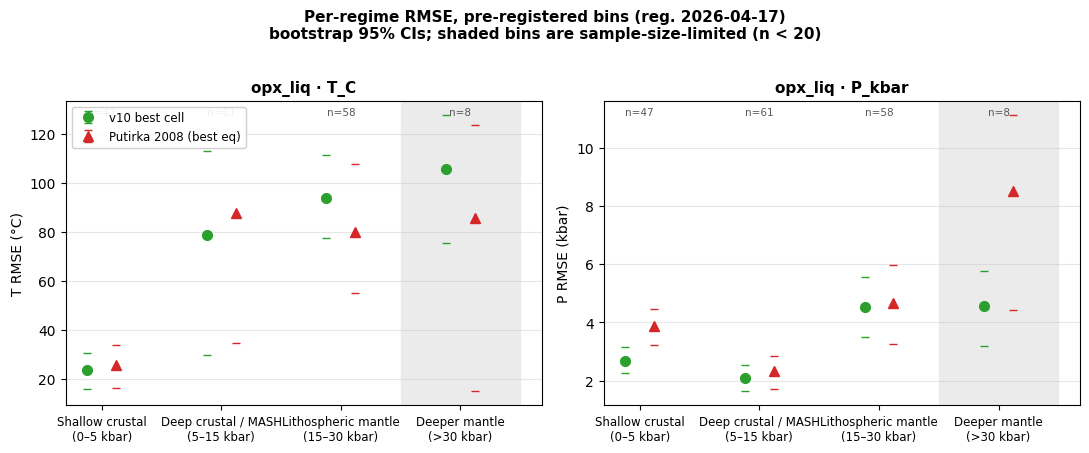

In [11]:
PRETTY = {
    'shallow_crustal':     'Shallow crustal\n(0\u20135 kbar)',
    'deep_crustal_MASH':   'Deep crustal / MASH\n(5\u201315 kbar)',
    'lithospheric_mantle': 'Lithospheric mantle\n(15\u201330 kbar)',
    'deeper_mantle':       'Deeper mantle\n(>30 kbar)',
}

def _err(r):
    if not (np.isfinite(r.rmse_lo) and np.isfinite(r.rmse_hi)):
        return 0.0, 0.0
    return max(0.0, r.rmse - r.rmse_lo), max(0.0, r.rmse_hi - r.rmse)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=False)

for ax, target, ylab in zip(axes, ('T_C', 'P_kbar'),
                             ('T RMSE (\u00b0C)', 'P RMSE (kbar)')):
    sub = df_opx[df_opx.target == target]
    regimes = [r for r in P_REGIME_LABELS if (sub.regime == r).any()]
    x = np.arange(len(regimes))

    v10 = sub[sub.method_family == 'v10']
    put = sub[sub.method_family == 'Putirka']

    v10_best = (v10.loc[v10.groupby('regime')['rmse'].idxmin()]
                   .set_index('regime'))
    put_best = (put.loc[put.groupby('regime')['rmse'].idxmin()]
                   .set_index('regime') if not put.empty else None)

    # Sample-size-limited shading + n annotation.
    for xi, r in enumerate(regimes):
        n = int(sub[sub.regime == r]['n'].iloc[0])
        if n < P_REGIME_MIN_N_FOR_CLAIMS:
            ax.axvspan(xi - 0.5, xi + 0.5, color='0.92', zorder=0)
        ax.annotate(f'n={n}', (xi, 0.98), xycoords=('data', 'axes fraction'),
                    ha='center', va='top', fontsize=7.5, color='0.35')

    # v10 best cell.
    y, elo, ehi, labs = [], [], [], []
    for r in regimes:
        if r in v10_best.index:
            row = v10_best.loc[r]
            y.append(row.rmse); l, h = _err(row); elo.append(l); ehi.append(h)
            labs.append(row['method'])
        else:
            y.append(np.nan); elo.append(0); ehi.append(0); labs.append('')
    ax.errorbar(x - 0.12, y, yerr=[elo, ehi], fmt='o', color='#2ca02c',
                ecolor='#2ca02c', capsize=3, markersize=7, linewidth=0,
                label='v10 best cell', zorder=6)

    # Putirka best equation.
    if put_best is not None:
        y2, elo2, ehi2, labs2 = [], [], [], []
        for r in regimes:
            if r in put_best.index:
                row = put_best.loc[r]
                y2.append(row.rmse); l, h = _err(row)
                elo2.append(l); ehi2.append(h); labs2.append(row['method'])
            else:
                y2.append(np.nan); elo2.append(0); ehi2.append(0); labs2.append('')
        ax.errorbar(x + 0.12, y2, yerr=[elo2, ehi2], fmt='^', color='#d62728',
                    ecolor='#d62728', capsize=3, markersize=7, linewidth=0,
                    label='Putirka 2008 (best eq)', zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels([PRETTY[r] for r in regimes], fontsize=8.5)
    ax.set_ylabel(ylab, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title(f'opx_liq · {target}', fontsize=11, weight='bold')
    if target == 'T_C':
        ax.legend(loc='upper left', fontsize=8.5, framealpha=0.92)

fig.suptitle(
    'Per-regime RMSE, pre-registered bins (reg. 2026-04-17)\n'
    'bootstrap 95% CIs; shaded bins are sample-size-limited (n < 20)',
    fontsize=11, weight='bold', y=1.02)
fig.tight_layout()

for ext in ('pdf', 'png'):
    outp = ROOT / 'figures' / f'fig_nb04_per_regime_rmse_opx_liq.{ext}'
    fig.savefig(outp, dpi=300, bbox_inches='tight')
    print(f'saved {outp}')
plt.show()

### Tone guardrail audit: which claims meet the honesty bar

**Input:** `opx_per_regime` from the headline cell.

**Output:** `claims_audit` — DataFrame of (regime, target, verdict) where verdict is one of `'v10 outperforms Putirka'`, `'competitive with Putirka'`, `'Putirka outperforms v10'`, or `'insufficient data'`. Saved to `results/v10_opx_per_regime_claims_audit.csv`.

**Method:** for every (regime, target), the honesty bar for an "outperforms" verdict is (i) non-overlapping bootstrap 95% CIs AND (ii) n >= 20. Otherwise the verdict is `'competitive with'` (CIs overlap, sufficient n) or `'insufficient data'` (n < 20).

**Connection:** every "beats" or "outperforms" claim in the manuscript must be backed by a matching verdict in this table. Consumed by `manuscripts/opx_2026/text/regime_results_autofilled.md` (D5).

**Why:** overclaiming — especially on small-n bins — is the single most common mistake in per-regime reporting. This explicit audit makes the risk impossible to ignore.

In [12]:
def _verdict(row):
    if row.get('sample_size_limited', True):
        return 'insufficient data (n < 20)'
    if row.get('ci_overlap') is None or row.get('ci_overlap') is True:
        return 'competitive with Putirka (CIs overlap)'
    if row.get('v10_rmse', np.nan) < row.get('putirka_rmse', np.nan):
        return 'v10 outperforms Putirka'
    return 'Putirka outperforms v10'


claims = opx_per_regime.copy()
claims['verdict'] = claims.apply(_verdict, axis=1)
claims_audit = claims[['regime', 'target', 'n', 'sample_size_limited',
                        'v10_rmse', 'putirka_rmse', 'ci_overlap', 'verdict']]
audit_path = RESULTS / 'v10_opx_per_regime_claims_audit.csv'
claims_audit.to_csv(audit_path, index=False)
print(f'saved {audit_path}')
print('\nClaim audit (opx_liq, pre-registered bins):\n')
print(claims_audit.to_string(index=False))

print('\n--- Manuscript-ready summary ---')
for _, r in claims_audit.iterrows():
    print(f'  {r.regime:22s} {r.target:7s} n={r.n:3d}  {r.verdict}')

saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_opx_per_regime_claims_audit.csv

Claim audit (opx_liq, pre-registered bins):

             regime target  n  sample_size_limited   v10_rmse  putirka_rmse  ci_overlap                                verdict
    shallow_crustal    T_C 47                False  23.469506     25.523865        True competitive with Putirka (CIs overlap)
    shallow_crustal P_kbar 47                False   2.662906      3.886364       False                v10 outperforms Putirka
  deep_crustal_MASH    T_C 61                False  78.464309     87.478245        True competitive with Putirka (CIs overlap)
  deep_crustal_MASH P_kbar 61                False   2.078945      2.314434        True competitive with Putirka (CIs overlap)
lithospheric_mantle    T_C 58                False  93.698294     79.652093        True competitive with Putirka (CIs overlap)
lithospheric_mantle P_kbar 58                False   4.538470      4.659726        True competi